# Create Train-Validate-Test Splits

**Use downsampled data**

Author: Pete King

We create a new set of train-validation-test splits using the downsampled data.

In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import pandas as pd

import data_prep as dp

In [2]:
# Select the data files and start dates for validation and testing
DOWNSAMPLE_FOLDER = 'data/downsample/W/'
ETF_FILENAME = DOWNSAMPLE_FOLDER + 'etf_downsample.csv'
INDICIES_FILENAME = DOWNSAMPLE_FOLDER + 'indicies_downsample.csv'
FRED_FILENAME = DOWNSAMPLE_FOLDER + 'fred_downsample.csv'
VALIDATION_START_DATE = '2023-01-01'
TESTING_START_DATE = '2024-10-01'
BUFFER_SIZE = 21  # Number of business days between splits

In [3]:
# Import feature datasets
etf_df = pd.read_csv(
    ETF_FILENAME,
    index_col='date',
    parse_dates=True
)
indicies_df = pd.read_csv(
    INDICIES_FILENAME,
    index_col='date',
    parse_dates=True
)
fred_df = pd.read_csv(
    FRED_FILENAME,
    index_col='date',
    parse_dates=True
)

In [4]:
# Merge the ETF, indicies, and FRED data
# All downsampled DataFrames are indexed by Sundays, so we simply concatenate
complete_df = pd.concat(
    [fred_df, indicies_df, etf_df], axis=1, join='outer', sort=True
)

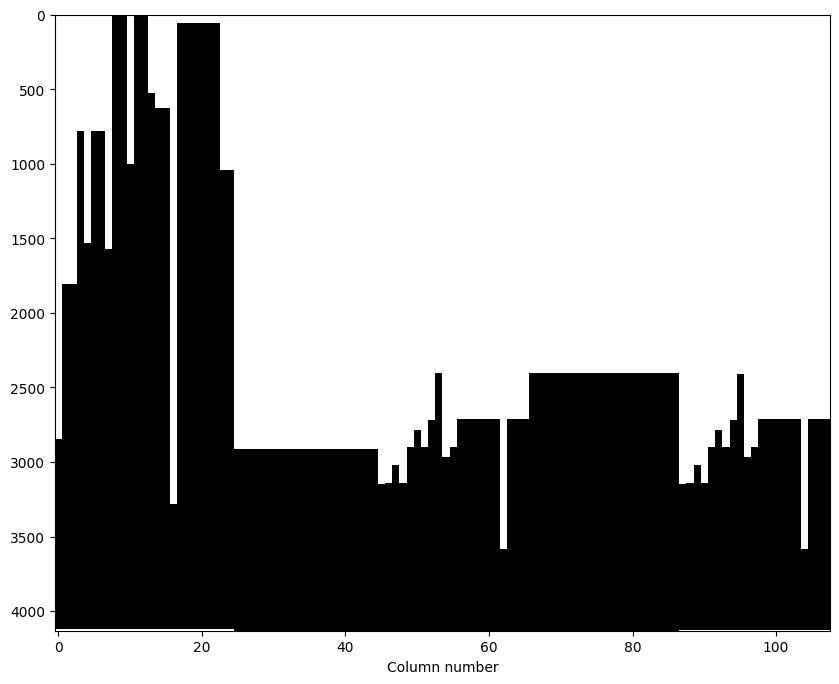

In [5]:
dp.view_nan(complete_df);

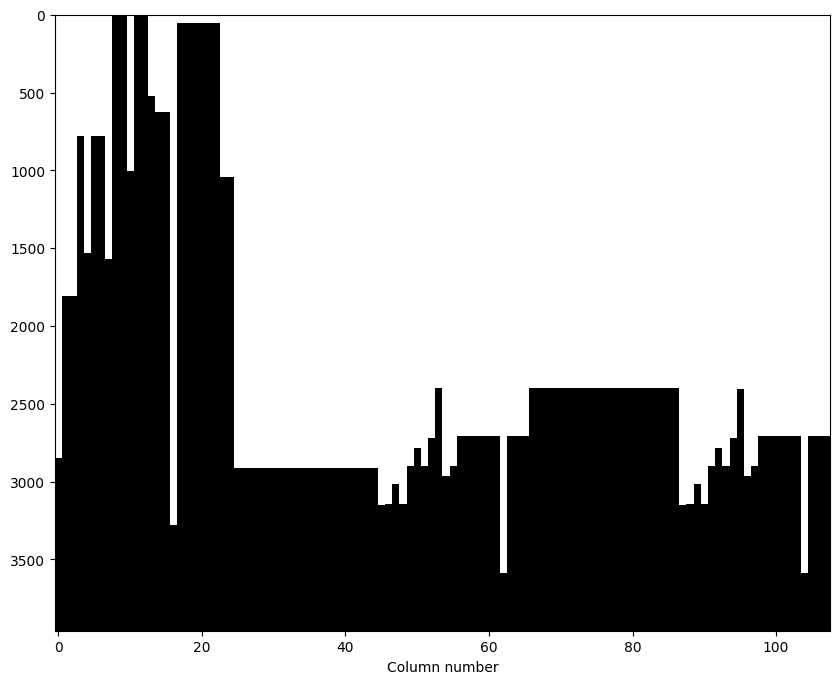

In [6]:
# Create separate training/validation and testing data files
train_val_df, test_df = dp.time_series_split(
    complete_df, TESTING_START_DATE, BUFFER_SIZE
)
train_df, val_df = dp.time_series_split(
    train_val_df, VALIDATION_START_DATE, BUFFER_SIZE
)
dp.view_nan(train_df);

In [7]:
# Drop NA rows from the training DF so we have a common start date
train_df = train_df.dropna().copy()
train_df

,one_month_yield_diff,three_month_yield_diff,six_month_yield_diff,one_year_yield_diff,two_year_yield_diff,five_year_yield_diff,ten_year_yield_diff,thirty_year_yield_diff,nominal_GDP_chg,real_GDP_chg,...,XLB_vol_target,XLE_vol_target,XLF_vol_target,XLI_vol_target,XLK_vol_target,XLP_vol_target,XLRE_vol_target,XLU_vol_target,XLV_vol_target,XLY_vol_target
date,,,,,,,,,,,,,,,,,,,,,
2015-10-11,0.01,0.00,0.01,0.02,0.04,0.06,0.05,0.04,0.001821,0.001845,...,0.008685,0.014335,0.010615,0.008700,0.009887,0.007447,0.011214,0.010561,0.011136,0.007058
2015-10-18,0.03,0.00,-0.01,-0.04,-0.03,0.00,-0.02,-0.02,0.001821,0.001845,...,0.010269,0.016518,0.010174,0.008688,0.011179,0.008087,0.010987,0.011092,0.010862,0.009160
2015-10-25,-0.05,-0.01,0.01,0.01,0.05,0.08,0.05,0.01,0.001821,0.001845,...,0.008756,0.016303,0.009877,0.007007,0.008792,0.007822,0.011115,0.011355,0.010705,0.009689
2015-11-01,0.00,0.06,0.07,0.09,0.09,0.11,0.09,0.06,0.001821,0.001845,...,0.008336,0.015298,0.008124,0.006583,0.008158,0.007986,0.012120,0.011174,0.010782,0.009801
2015-11-08,0.03,0.00,0.05,0.10,0.13,0.16,0.14,0.14,0.001821,0.001845,...,0.011092,0.017739,0.010715,0.008546,0.010002,0.009012,0.011371,0.009822,0.012103,0.011185
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-13,-0.07,-0.01,-0.10,-0.21,-0.38,-0.44,-0.40,-0.31,0.016487,0.006902,...,0.011709,0.017206,0.009908,0.009259,0.016462,0.007887,0.013614,0.011588,0.008435,0.013501
2022-11-20,0.21,0.00,0.06,0.11,0.11,-0.01,-0.06,-0.15,0.016487,0.006902,...,0.013718,0.016997,0.010618,0.010363,0.018469,0.008038,0.013786,0.010203,0.009563,0.013949
2022-11-27,0.19,0.00,0.02,0.01,-0.06,-0.12,-0.15,-0.17,0.016487,0.006902,...,0.013166,0.017987,0.011071,0.011365,0.019000,0.008034,0.013947,0.010483,0.009697,0.015092


In [8]:
val_df = val_df.dropna().copy()
val_df

,one_month_yield_diff,three_month_yield_diff,six_month_yield_diff,one_year_yield_diff,two_year_yield_diff,five_year_yield_diff,ten_year_yield_diff,thirty_year_yield_diff,nominal_GDP_chg,real_GDP_chg,...,XLB_vol_target,XLE_vol_target,XLF_vol_target,XLI_vol_target,XLK_vol_target,XLP_vol_target,XLRE_vol_target,XLU_vol_target,XLV_vol_target,XLY_vol_target
date,,,,,,,,,,,,,,,,,,,,,
2023-01-01,0.25,-0.04,0.00,-0.02,0.09,0.05,0.04,0.04,0.016658,0.007239,...,0.012904,0.016025,0.010254,0.011618,0.015070,0.010140,0.015181,0.010137,0.007718,0.015778
2023-01-08,0.15,0.14,0.02,-0.01,-0.16,-0.25,-0.24,-0.21,0.016658,0.007239,...,0.010789,0.015455,0.008576,0.009779,0.015444,0.008290,0.013133,0.009061,0.007474,0.017260
2023-01-15,0.21,-0.03,-0.06,0.00,0.03,-0.06,-0.04,-0.05,0.016658,0.007239,...,0.010546,0.017213,0.008959,0.009963,0.015416,0.008824,0.010867,0.010850,0.007020,0.016667
2023-01-22,0.09,0.01,-0.02,0.01,-0.04,-0.04,-0.05,0.02,0.016658,0.007239,...,0.009977,0.018718,0.008281,0.009140,0.015454,0.006744,0.011117,0.010495,0.007419,0.017707
2023-01-29,-0.08,0.00,-0.01,-0.02,-0.02,0.01,0.00,-0.05,0.016658,0.007239,...,0.010178,0.017522,0.007637,0.008890,0.015221,0.006970,0.011723,0.010896,0.007873,0.016667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-11,0.02,-0.02,0.11,0.16,0.16,0.18,0.16,0.17,0.012510,0.008248,...,0.009145,0.012096,0.008350,0.008880,0.018223,0.005262,0.007394,0.005565,0.005444,0.014366
2024-08-18,0.00,0.00,0.00,0.02,0.05,0.02,-0.01,-0.04,0.012510,0.008248,...,0.008864,0.012509,0.007909,0.008572,0.017447,0.005704,0.007489,0.006405,0.005304,0.011921
2024-08-25,0.00,-0.06,-0.08,-0.12,-0.16,-0.10,-0.05,-0.01,0.012510,0.008248,...,0.009412,0.011138,0.008071,0.009257,0.017305,0.005791,0.006427,0.008930,0.005147,0.011434


In [9]:
test_df = test_df.dropna().copy()
test_df

,one_month_yield_diff,three_month_yield_diff,six_month_yield_diff,one_year_yield_diff,two_year_yield_diff,five_year_yield_diff,ten_year_yield_diff,thirty_year_yield_diff,nominal_GDP_chg,real_GDP_chg,...,XLB_vol_target,XLE_vol_target,XLF_vol_target,XLI_vol_target,XLK_vol_target,XLP_vol_target,XLRE_vol_target,XLU_vol_target,XLV_vol_target,XLY_vol_target
date,,,,,,,,,,,,,,,,,,,,,
2024-10-06,0.08,0.00,0.07,0.22,0.27,0.23,0.17,0.12,0.010624,0.004599,...,0.006608,0.011264,0.008491,0.006820,0.012020,0.005284,0.009470,0.012055,0.006427,0.010572
2024-10-13,-0.03,-0.04,-0.01,-0.06,-0.04,0.02,0.05,0.09,0.010624,0.004599,...,0.007259,0.012606,0.015406,0.010928,0.013507,0.006390,0.012111,0.012057,0.006328,0.013756
2024-10-20,-0.01,0.00,0.03,0.01,0.00,0.02,0.05,0.06,0.010624,0.004599,...,0.008369,0.010882,0.015164,0.011412,0.013461,0.006614,0.012096,0.011590,0.008167,0.014674
2024-10-27,-0.03,0.00,0.04,0.05,0.09,0.09,0.06,0.02,0.010624,0.004599,...,0.008417,0.012053,0.015453,0.011747,0.013289,0.006899,0.011490,0.011561,0.008351,0.013004
2024-11-03,-0.13,-0.09,-0.04,0.00,0.09,0.11,0.09,0.04,0.010624,0.004599,...,0.007736,0.011597,0.015064,0.011731,0.011021,0.006785,0.011126,0.010815,0.008222,0.012415
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-30,0.02,-0.03,-0.02,0.00,0.01,-0.02,-0.02,-0.01,0.011076,0.001628,...,0.008268,0.012054,0.007011,0.008513,0.010991,0.004778,0.005316,0.008254,0.008106,0.007726
2025-12-07,-0.16,-0.10,-0.07,-0.01,0.02,0.05,0.05,0.05,0.011076,0.001628,...,0.010667,0.014556,0.008545,0.010213,0.011261,0.005304,0.005798,0.008829,0.008615,0.008581
2025-12-14,-0.06,-0.10,-0.11,-0.07,-0.05,0.00,0.02,0.04,0.011076,0.001628,...,0.009831,0.016586,0.008522,0.009555,0.010444,0.008467,0.006355,0.008827,0.007559,0.009170


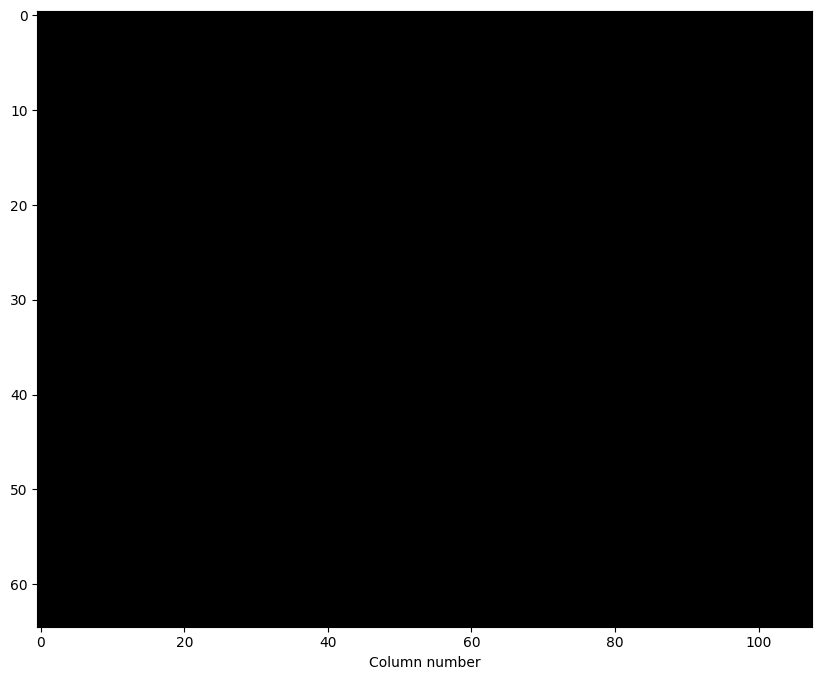

In [10]:
dp.view_nan(test_df);

In [11]:
# Get column names for breaking out separate datasets by type
etf_cols = [column for column in etf_df.columns]
fred_cols = [column for column in fred_df.columns]
indicies_cols = [column for column in indicies_df.columns]

In [12]:
DATA_FOLDER  = DOWNSAMPLE_FOLDER + 'train-val-test/'
# Save complete segmented datasets
train_df.to_csv(DATA_FOLDER + 'train_base_data.csv')
val_df.to_csv(DATA_FOLDER + 'val_base_data.csv')
test_df.to_csv(DATA_FOLDER + 'test_base_data.csv')
"""
# At this point we don't need to break out separate CSV subsets
# Instead we will merge in PCA data with the ALL_DATA subsets
# Save ETF datasets
train_df[etf_cols].to_csv(DATA_FOLDER + 'train_etf_data.csv')
val_df[etf_cols].to_csv(DATA_FOLDER + 'val_etf_data.csv')
test_df[etf_cols].to_csv(DATA_FOLDER + 'test_etf_data.csv')

# Save FRED datasets
train_df[fred_cols].to_csv(DATA_FOLDER + 'train_fred_data.csv')
val_df[fred_cols].to_csv(DATA_FOLDER + 'val_fred_data.csv')
test_df[fred_cols].to_csv(DATA_FOLDER + 'test_fred_data.csv')

# Save index datasets
train_df[indicies_cols].to_csv(DATA_FOLDER + 'train_indicies_data.csv')
val_df[indicies_cols].to_csv(DATA_FOLDER + 'val_indicies_data.csv')
test_df[indicies_cols].to_csv(DATA_FOLDER + 'test_indicies_data.csv')
""";